## KLASIFIKASI JENIS JAMUR AGARICUS DAN AMANITA MENGGUNAKAN EKSTRAKSI FITUR GLCM DAN METODE KNN, SVM, SERTA RANDOM FOREST

#### Import Library

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import random

Kode di atas mengimpor berbagai library yang dibutuhkan untuk membuat sistem klasifikasi gambar jamur. `os` dipakai untuk bekerja dengan struktur folder dan nama berkas, sementara `cv2` dari OpenCV dipakai untuk memuat dan memproses gambar. `matplotlib.pyplot` digunakan untuk menampilkan grafik dan citra, `numpy` untuk perhitungan numerik dan array, serta `pandas` untuk menyusun data menjadi tabel yang mudah dianalisis. Dari `sklearn.model_selection` diambil fungsi untuk membagi data menjadi bagian latih dan uji, dan `cross_val_predict` untuk evaluasi model. Metode evaluasi seperti `accuracy_score`, `classification_report`, `precision_score`, `recall_score`, `f1_score`, serta `confusion_matrix` diimpor dari `sklearn.metrics` untuk menilai kinerja model. Untuk ekstraksi fitur tekstur dari gambar, digunakan `graycomatrix` dan `graycoprops` dari `skimage.feature`, serta `entropy` dari `scipy.stats` untuk menghitung entropi. Untuk membangun model klasifikasi, diimpor `RandomForestClassifier`, `SVC`, dan `KNeighborsClassifier`. `ConfusionMatrixDisplay` juga diimpor untuk memvisualisasikan matriks kebingungan, dan `SelectKBest` serta `f_classif` dipakai apabila ingin melakukan seleksi fitur berdasarkan statistik. Terakhir `seaborn` digunakan untuk visualisasi data yang lebih baik, dan `random` untuk pengacakan yang konsisten.

## Data Loading

In [2]:
data = []
labels = []
file_name = []

dataset_path = "dataset" 

target_folders = ["Agaricus", "Amanita"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (640, 480))
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Agaricus', 'Amanita'], dtype='<U8'), array([100, 100]))


Kode di atas digunakan untuk memuat gambar dari folder "dataset" untuk dua kelas target yaitu "Agaricus" dan "Amanita". Pertama dibuat tiga daftar kosong untuk menyimpan citra (data), label kelas (labels), dan nama berkas (file_name). Lalu setiap subfolder dalam folder dataset diperiksa: jika bukan folder atau bukan salah satu dari dua kelas target, subfolder itu dilewati. Untuk setiap berkas gambar di subfolder yang valid, gambar dibaca dengan OpenCV; jika pembacaan sukses (tidak None) gambar dikonversi ke skala abu-abu, diubah ukuran menjadi 640x480 piksel, dan dipaksa ke tipe uint8. Gambar yang telah diproses ditambahkan ke daftar data, nama subfolder (sebagai label kelas) ditambahkan ke daftar labels, dan nama file disimpan di file_name. Setelah semua gambar diproses, daftar diubah menjadi array NumPy untuk mempermudah pengolahan selanjutnya, dan dua baris print menampilkan jumlah total gambar yang dimuat serta distribusi label untuk memastikan proses loading berhasil.

## Data Preparation

### Difine Preprocessing

In [3]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

Fungsi grayscale di atas mengecek dulu bentuk array gambar: jika sudah 2 dimensi (sudah abu‑abu) langsung dikembalikan, kalau berdimensi 3 diasumsikan punya 3 kanal warna (RGB) lalu diubah ke skala abu‑abu dengan rumus luminositas (0.299*R + 0.587*G + 0.114*B) agar hasilnya merefleksikan kecerahan yang lebih mirip mata manusia, lalu dikonversi ke tipe uint8; jika input bukan 2D atau 3D fungsi akan menolak dengan ValueError. Fungsi resize membuat citra baru berukuran (new_width, new_height) dengan metode penyesuaian sederhana (nearest‑neighbor): ia membentuk array kosong untuk ukuran tujuan, lalu untuk setiap piksel tujuan menghitung koordinat sumber (x,y) dengan perbandingan skala antara lebar/tinggi lama dan baru, menyalin nilai piksel dari posisi sumber tersebut ke posisi tujuan, dan mengembalikan citra yang diubah ukurannya.

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Fungsi `convolution`  di atas ini digunakan untuk melakukan operasi konvolusi pada gambar, yaitu teknik pemrosesan gambar yang sangat umum digunakan dalam berbagai aplikasi seperti penajaman dan penghalusan citra. Operasi konvolusi bekerja dengan menggeserkan sebuah matriks kecil yang disebut kernel ke seluruh permukaan gambar, dan pada setiap posisi kernel melakukan perkalian elemen dengan elemen terhadap bagian gambar yang sesuai, kemudian menjumlahkan hasilnya.

Pada awal fungsi, kode mengambil ukuran kernel dengan `size = kernel.shape[0]` untuk mengetahui dimensi kernel yang akan digunakan. Kemudian `pad_size` dihitung dengan membagi ukuran kernel dengan 2 menggunakan operasi pembagian bulat. Padding ini diperlukan untuk memperluas tepi gambar asli agar hasil konvolusi memiliki ukuran yang sama dengan gambar masukan. Gambar asli kemudian dipadding menggunakan `np.pad()` dengan mode 'constant', yang berarti tepi gambar akan diisi dengan nilai nol.

Setelah itu, fungsi membuat kanvas kosong bernama `canvas` yang memiliki bentuk sama dengan gambar asli menggunakan `np.zeros_like(img)`, dan mengubah tipe data menjadi float32 untuk menangani nilai-nilai yang mungkin melebihi rentang uint8. Kemudian tinggi dan lebar gambar diambil untuk digunakan dalam loop. Loop ganda `for i` dan `for j` akan mengiterasi setiap piksel dalam gambar. Pada setiap posisi, fungsi mengekstrak region (bagian) dari gambar yang sudah dipadding dengan ukuran yang sama dengan kernel menggunakan slicing `padded[i:i+size, j:j+size]`. Region ini kemudian dikalikan elemen demi elemen dengan kernel, dan hasilnya dijumlahkan menggunakan `np.sum()` sebelum disimpan di `canvas[i, j]`. Akhirnya, fungsi mengembalikan `canvas` yang berisi hasil konvolusi lengkap dari seluruh gambar.

In [5]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

Kode diatas itu mendefinisikan dua matriks kecil yang dipakai sebagai kernel dalam operasi konvolusi pada citra: kernelSmoothing adalah kernel penghalus yang memberikan bobot hampir sama pada piksel sekitar dengan bobot tengah sedikit lebih besar (0.2) sehingga total bobot = 1, efeknya merata‑rata nilai piksel untuk meredam noise dan membuat citra lebih lembut tanpa mengubah kecerahan keseluruhan; kernelSharpening memberi bobot besar pada piksel pusat (8/9) dan bobot kecil pada tetangga (1/9) sehingga menonjolkan perbedaan lokal (tepi dan detail)—karena jumlah elemennya lebih dari 1 maka dapat memperkuat intensitas sehingga sering dinormalisasi (dibagi jumlah elemen) setelah konvolusi, seperti yang dilakukan di sel lain; penggunaan dtype=np.float32 bertujuan untuk akurasi dan efisiensi perhitungan sebelum hasilnya diklip ke rentang 0–255 dan dikonversi kembali ke uint8.

In [6]:
def filter(img, size, mode):
    height, width = img.shape

    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros((height, width), dtype=np.float32)

    match mode:
        case 'mean':
            area = size * size

            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    total = 0
                    for row in region:
                        for val in row:
                            total += int(val)

                    mean_val = total / area
                    canvas[i, j] = mean_val

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    values = region.ravel().tolist()
                    values.sort()

                    mid = len(values) // 2
                    median_val = values[mid]

                    canvas[i, j] = median_val

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    values = region.ravel()

                    count = {}
                    for val in values:
                        val = int(val)
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = mode_val

        case _:
            raise ValueError("Mode harus 'mean', 'median', atau 'modus'.")
    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi `filter` di atas digunakan untuk memproses gambar secara local dengan cara melihat setiap piksel bersama tetangganya pada sebuah jendela berukuran `size x size`, lalu mengganti nilai piksel tengah berdasarkan aturan yang dipilih melalui parameter `mode`. Di awal fungsi, tinggi dan lebar gambar ditentukan dari `img.shape`, lalu gambar dipadding di sekelilingnya dengan cara menyalin nilai tepi menggunakan `np.pad(..., mode='edge')`, agar saat jendela bergerak di tepi gambar masih ada data yang tersedia. Kanvas kosong `canvas` dibuat dengan ukuran sama seperti gambar asli untuk menampung hasil pemrosesan.

Jika `mode` bernilai `'mean'`, maka setiap wilayah `size x size` dihitung rata-ratanya dengan menjumlahkan semua nilai piksel di dalam wilayah itu lalu dibagi banyak piksel, kemudian nilai rata-rata tersebut disimpan ke piksel tengah pada `canvas`. Jika `mode` adalah `'median'`, semua nilai piksel dalam wilayah diubah menjadi satu daftar lalu diurutkan, kemudian nilai tengah daftar dipilih sebagai nilai baru sehingga efeknya mampu mengurangi noise dengan lebih baik dibanding rata-rata. Untuk `mode` `'modus'`, fungsi menghitung nilai yang paling sering muncul di dalam wilayah tersebut, kemudian menggunakan nilai tersebut sebagai nilai baru pada piksel tengah; ini bagus untuk mempertahankan warna atau intensitas yang dominan dalam area kecil. Kalau `mode` bukan salah satu dari tiga pilihan itu, fungsi akan memunculkan kesalahan dengan pesan bahwa mode harus `'mean'`, `'median'`, atau `'modus'`.

Setelah seluruh piksel diproses, hasil di dalam `canvas` dipastikan berada di rentang 0 hingga 255 dengan `np.clip` dan dikonversi kembali ke tipe `uint8`, sehingga hasil akhirnya adalah gambar abu-abu yang sudah difilter sesuai pilihan.

## Preprocessing

Kode  di bawah ini membuat proses preprocessing gambar lalu menampilkan hasilnya untuk setiap kelas. Fungsi `percobaan2` menerima satu gambar, mengubahnya dulu ke skala abu-abu dengan fungsi `grayscale`, lalu mengubah ukurannya menjadi 640x480 piksel dengan fungsi `resize`. Setelah itu gambar diproses dengan konvolusi menggunakan kernel `kernelSharpening` untuk menajamkan detail, hasil konvolusi dinormalisasi dengan membagi jumlah nilai kernel agar intensitas tetap terkontrol, kemudian dipotong ke rentang 0–255 dan dikonversi jadi `uint8`. Selanjutnya hasil penajaman diberi konvolusi lagi dengan kernel `kernelSmoothing` untuk meredam noise dan memperhalus citra, lalu kembali dipotong dan dikonversi ke tipe yang sama. Jadi keluaran fungsi ini adalah gambar yang sudah distandarkan, lebih tajam namun tidak terlalu kasar.

Baris `dataPreprocessed = [percobaan2(img) for img in data]` menjalankan fungsi itu untuk semua gambar dalam dataset, sehingga semua gambar disimpan dalam daftar baru sebagai hasil preprocessing. Kemudian `unique_labels = sorted(set(labels))` mengambil nama kelas yang unik dari label dan mengurutkannya. Loop berikutnya akan membuat sebuah tampilan visual untuk setiap kelas: ia mencari indeks semua gambar untuk kelas tersebut, membuat subplot berukuran 4x6 untuk menampilkan 24 gambar, memberi judul yang menunjukkan kelasnya, lalu setiap sel dipakai untuk menampilkan salah satu gambar hasil preprocess dengan skala abu-abu dan tanpa sumbu. Akhirnya setiap figure ditata rapih dengan `tight_layout` dan ditampilkan.

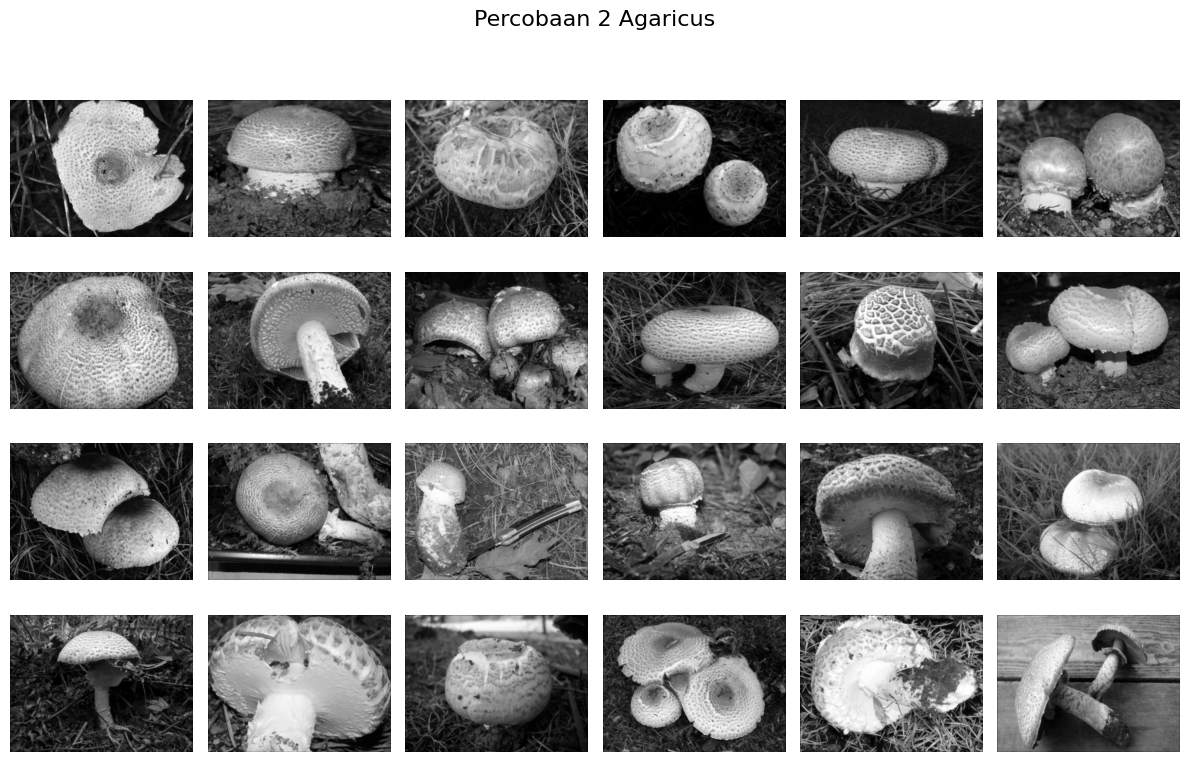

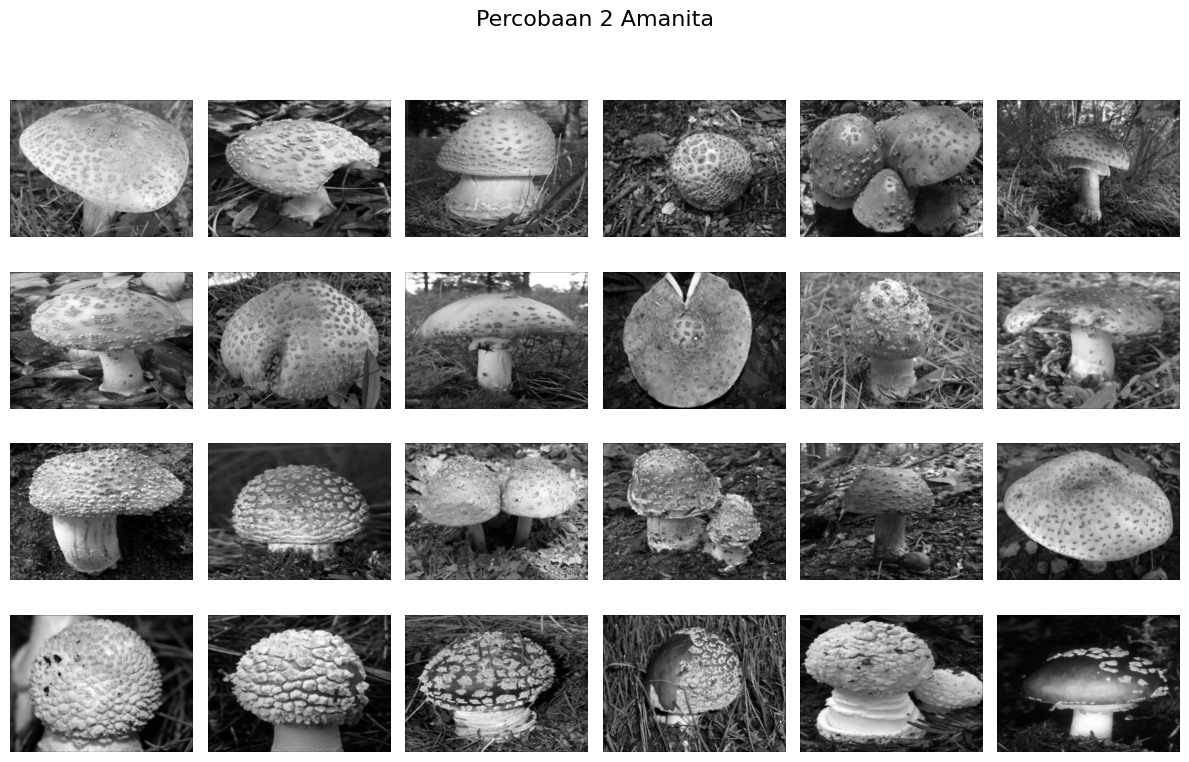

In [7]:
def percobaan2(img):
    img_gray = grayscale(img)
    img_resize = resize(img_gray, 640, 480)

    sharpening = convolution(img_resize, kernelSharpening)
    sharpening = sharpening / np.sum(kernelSharpening)
    sharpening = np.clip(sharpening, 0, 255).astype(np.uint8)

    smoothing = convolution(sharpening, kernelSmoothing)
    smoothing = np.clip(smoothing, 0, 255).astype(np.uint8)

    mode3x3 = filter(smoothing, 3, 'modus')
    return mode3x3

dataPreprocessed = [percobaan2(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 2 {label}', fontsize=16)
    
    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) 
    plt.show()

## Ekstraksi Fitur

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi di atas ini menerima citra (array intensitas, idealnya abu‑abu) dan sebuah pilihan sudut dalam derajat, lalu mengubah pilihan sudut tersebut menjadi nilai radian yang sesuai (0, 45, 90, atau 135 derajat) — jika nilai sudut bukan salah satu dari empat opsi itu fungsi akan memunculkan error. Setelah menentukan sudut, fungsi memanggil graycomatrix dari skimage untuk menghitung GLCM (gray‑level co‑occurrence matrix) dengan jarak 1 piksel, 256 level intensitas, serta opsi symmetric=True dan normed=True; GLCM ini adalah matriks yang merekam berapa sering pasangan nilai intensitas muncul berdekatan pada arah dan jarak tertentu sehingga berguna untuk mengekstrak fitur tekstur, dan pengaturan symmetric/normed membuat matriksnya simetris dan ternormalisasi sehingga lebih stabil untuk perhitungan fitur selanjutnya — hasil GLCM lalu dikembalikan oleh fungsi.

In [9]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Fungsi‑fungsi di atas ini mengambil sebuah GLCM (gray‑level co‑occurrence matrix) dan mengembalikan nilai jumlah tunggal untuk tiap fitur tekstur: masing‑masing wrapper memanggil graycoprops lalu mengambil elemen [0,0] karena graycoprops mengembalikan array dengan dimensi jarak/sudut sehingga kita ambil kombinasi jarak=0/sudut=0 yang dipakai di kode ini. Secara singkat, "correlation" mengukur sejauh mana intensitas piksel berpasangan saling berkaitan (ketergantungan linier), "dissimilarity" memberi ukuran seberapa berbeda pasangan nilai (semakin besar = lebih berbeda), "homogeneity" (homogenity) mengukur seberapa seragam atau halus tekstur (nilai besar = lebih homogen), "contrast" menilai perbedaan intensitas lokal atau kekasaran tepi (nilai besar = kontras/tepi lebih kuat), "ASM" (angular second moment) merepresentasikan keteraturan/ketertiban distribusi (nilai besar = lebih teratur), dan "energy" menunjukkan kekuatan/kemantapan pola tekstur (serupa dengan ASM, nilai besar = pola dominan). Fungsi entropyGlcm menghitung entropi dari matriks (dengan scipy.stats.entropy pada matriks yang diratakan), yang memberi ukuran ketidakpastian atau kompleksitas tekstur—semakin tinggi entropi, semakin acak/beragam teksturnya.

## Ekstraksi Fitur GLCM

Fungsi `ekstrak_fitur_glcm` di bawah digunakan untuk mengambil fitur-fitur tekstur penting dari setiap gambar menggunakan metode GLCM (Gray Level Co-occurrence Matrix). Fungsi ini menerima dua parameter: `data` yang berisi kumpulan gambar yang sudah diproses, dan `nama_prepro` yang merupakan nama tahap preprocessing untuk keperluan dokumentasi dan pelacakan data.

Cara kerja fungsi ini dimulai dengan membuat daftar kosong bernama `fitur_list` untuk menyimpan semua fitur yang akan diekstrak. Kemudian fungsi melakukan loop untuk setiap gambar dalam dataset. Pada setiap iterasi, gambar terlebih dahulu dikonversi ke tipe data `uint8` (unsigned integer 8-bit) menggunakan `astype()` untuk memastikan kompatibilitas dengan fungsi GLCM. Setelah itu, fungsi memanggil `glcm()` dengan parameter sudut 0 derajat, yang menghasilkan matriks co-occurrence dari gambar tersebut pada arah horizontal.

Dari matriks GLCM yang dihasilkan, fungsi kemudian menghitung tujuh fitur tekstur yang berbeda-beda. Fitur-fitur ini dikumpulkan dalam sebuah kamus (dictionary) yang terdiri dari: contrast (mengukur kekasaran tekstur), correlation (mengukur ketergantungan nilai piksel), energy (mengukur kekuatan pola), homogeneity (mengukur keseragaman), dissimilarity (mengukur ketidakmiripan), ASM (mengukur keteraturan), dan entropy (mengukur kompleksitas). Setiap kamus fitur untuk satu gambar kemudian ditambahkan ke dalam `fitur_list`.

Setelah semua gambar selesai diproses, daftar fitur diubah menjadi DataFrame pandas untuk kemudahan analisis dan manipulasi data. Fungsi juga menambahkan kolom baru bernama `tahap` yang berisi nilai parameter `nama_prepro`, sehingga memudahkan identifikasi tahap preprocessing yang digunakan. Pada baris terakhir, fungsi `ekstrak_fitur_glcm` dipanggil dengan `dataPreprocessed` (gambar yang sudah melalui preprocessing) dan label `'percobaan2'`, kemudian hasilnya ditampilkan menggunakan `display()` untuk melihat tabel fitur yang telah diekstrak.

In [10]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan2')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,76.639189,0.990751,0.047778,0.515064,4.146648,0.002283,7.519417,percobaan2
1,47.370944,0.990847,0.034197,0.489210,3.690910,0.001169,7.835171,percobaan2
2,89.560081,0.988304,0.028058,0.440282,5.033522,0.000787,8.271364,percobaan2
3,39.505895,0.995901,0.102363,0.572919,2.792762,0.010478,6.847806,percobaan2
4,58.747463,0.992096,0.057811,0.519527,3.706612,0.003342,7.393809,percobaan2
...,...,...,...,...,...,...,...,...
195,130.470256,0.985337,0.027651,0.418641,6.059817,0.000765,8.407250,percobaan2
196,54.419451,0.991609,0.035555,0.496629,3.647072,0.001264,7.746559,percobaan2
197,52.170807,0.991629,0.081488,0.650680,2.296068,0.006640,6.329763,percobaan2
198,62.286929,0.975410,0.068880,0.601290,3.223171,0.004744,6.907096,percobaan2


In [11]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Penjelasan Ekstraksi Fitur GLCM dengan Empat Sudut

Kode di atas digunakan untuk mengekstrak fitur tekstur dari setiap gambar jamur menggunakan metode GLCM (Gray Level Co-occurrence Matrix) dengan empat arah sudut yang berbeda: 0, 45, 90, dan 135 derajat. Tujuan menggunakan empat sudut berbeda adalah untuk menangkap karakteristik tekstur dari berbagai arah, sehingga fitur yang dihasilkan lebih komprehensif dan dapat membedakan pola tekstur jamur dengan lebih akurat.

Bagian pertama kode membuat empat daftar kosong (Derajat0, Derajat45, Derajat90, Derajat135) untuk menyimpan matriks GLCM dari setiap gambar pada masing-masing sudut. Kemudian kode melakukan perulangan untuk setiap gambar dalam dataset yang sudah diproses sebelumnya (dataPreprocessed). Pada setiap iterasi, fungsi `glcm()` dipanggil empat kali dengan parameter sudut yang berbeda untuk menghasilkan matriks co-occurrence pada arah horizontal, diagonal 45 derajat, vertikal, dan diagonal 135 derajat. Setiap matriks GLCM yang dihasilkan disimpan dalam daftar yang sesuai.

Setelah menghasilkan semua matriks GLCM, kode kemudian membuat tujuh kelompok daftar kosong yang masing-masing akan menampung fitur tekstur berbeda: kontras (Kontras0 hingga Kontras135), ketidakmiripan (dissimilarity), keseragaman (homogenity), entropi (entropy), keteraturan angular second moment (ASM), energi (energy), dan korelasi (correlation). Setiap kelompok memiliki empat daftar untuk menyimpan nilai fitur pada keempat sudut tersebut.

Tahap berikutnya adalah ekstraksi tujuh fitur tekstur dari setiap matriks GLCM yang telah dibuat. Kode melakukan perulangan lima kali—masing-masing untuk menghitung satu jenis fitur pada keempat sudut. Pada setiap perulangan, kode mengambil masing-masing matriks GLCM dari empat sudut dan menghitung nilai fitur menggunakan fungsi khusus (seperti `correlation()`, `contrast()`, `dissimilarity()`, dan seterusnya), lalu nilai-nilai tersebut disimpan dalam daftar yang bersesuaian. Dengan cara ini, untuk setiap gambar dihasilkan 28 fitur (7 jenis fitur × 4 sudut), yang nantinya akan menjadi input untuk proses pembelajaran mesin guna membedakan antara jamur Agaricus dan Amanita.

## Hasil Ekstraksi ke CSV

In [12]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

## Penjelasan Kode Ekstraksi Fitur GLCM Lengkap

Kode di atas digunakan untuk mengumpulkan semua fitur tekstur yang telah dihitung sebelumnya dari setiap gambar jamur dan menyusunnya menjadi sebuah tabel yang rapi. Proses dimulai dengan membuat sebuah daftar kosong bernama `features` yang nantinya akan menampung semua fitur dari seluruh gambar dalam dataset.

Kemudian kode melakukan perulangan untuk setiap gambar yang sudah diproses dalam `dataPreprocessed`. Pada setiap perulangan, kode membuat sebuah daftar baru bernama `fitur` yang berisi 28 nilai fitur tekstur. Fitur-fitur ini diekstrak dari empat matriks GLCM yang telah dibuat sebelumnya (Derajat0, Derajat45, Derajat90, dan Derajat135), yang masing-masing mewakili arah sudut berbeda dari analisis tekstur. Untuk setiap sudut, tujuh jenis fitur dihitung: contrast (mengukur kekasaran), dissimilarity (mengukur ketidakmiripan), homogeneity (mengukur keseragaman), entropy (mengukur kompleksitas), ASM (mengukur keteraturan), energy (mengukur kekuatan pola), dan correlation (mengukur ketergantungan). Setelah semua 28 fitur dari satu gambar dikumpulkan dalam daftar `fitur`, daftar tersebut ditambahkan ke dalam daftar `features` yang lebih besar.

Setelah perulangan selesai dan semua fitur dari semua gambar telah dikumpulkan, kode membuat daftar berisi nama-nama kolom yang deskriptif untuk setiap fitur. Nama-nama kolom ini diformat dengan cara menggabungkan jenis fitur dengan derajat sudutnya (misalnya "contrast_0", "contrast_45", dll) sehingga memudahkan identifikasi setiap fitur. Terakhir, kode mengubah daftar fitur tersebut menjadi sebuah DataFrame pandas dengan menggunakan nama-nama kolom yang telah didefinisikan, menghasilkan tabel `df_fitur` yang berisi 28 kolom (satu untuk setiap fitur) dan 140 baris (satu untuk setiap gambar dalam dataset), sehingga data siap digunakan untuk tahap seleksi fitur dan pemodelan machine learning selanjutnya.

## Penjelasan Kode Penyusunan dan Penyimpanan Hasil Ekstraksi Fitur

Kode di bawah digunakan untuk mengorganisir semua fitur tekstur yang telah diekstrak dari setiap gambar jamur menjadi sebuah tabel yang terstruktur dan kemudian menyimpannya ke dalam berkas CSV. Proses dimulai dengan membuat sebuah kamus bernama `dataTable` yang berfungsi seperti kontainer untuk mengelompokkan data-data terkait. Dalam kamus ini, setiap kunci mewakili nama kolom yang akan muncul di tabel, sementara nilainya adalah daftar-daftar yang berisi data aktual. Misalnya, kunci 'Filename' memiliki nilai `file_name` yang merupakan daftar berisi nama-nama berkas gambar, sedangkan kunci 'Label' memiliki nilai `labels` yang berisi jenis jamur untuk setiap gambar (Agaricus atau Amanita).

Kamus `dataTable` juga mencakup semua 28 fitur tekstur yang telah dihitung sebelumnya dari empat sudut berbeda (0, 45, 90, dan 135 derajat). Fitur-fitur ini tersusun dalam kelompok berdasarkan jenisnya: Contrast (kontras), Homogeneity (keseragaman), Dissimilarity (ketidakmiripan), Entropy (entropi), ASM (keteraturan), Energy (energi), dan Correlation (korelasi). Setiap fitur memiliki empat varian sesuai dengan empat sudut analisis, sehingga total ada 28 kolom fitur ditambah 2 kolom informasi (Filename dan Label).

Setelah kamus `dataTable` selesai disusun, kode mengubahnya menjadi sebuah DataFrame pandas menggunakan perintah `pd.DataFrame(dataTable)`. DataFrame adalah struktur data tabular (seperti tabel spreadsheet) yang memudahkan manipulasi, analisis, dan visualisasi data. Pada tahap ini, DataFrame `df` memiliki 140 baris (satu untuk setiap gambar) dan 30 kolom (2 kolom informasi plus 28 kolom fitur). Selanjutnya, DataFrame ini disimpan ke dalam berkas CSV dengan nama 'hasil_ekstraksi_percobaan2.csv' menggunakan method `to_csv()` dengan parameter `index=False` agar nomor baris otomatis tidak disertakan dalam berkas.

Langkah terakhir adalah membaca kembali berkas CSV yang baru saja disimpan menggunakan `pd.read_csv()` dan menyimpannya dalam variabel `hasilEkstrak`. Proses membaca kembali ini berfungsi untuk memverifikasi bahwa data telah tersimpan dengan benar dan dapat diakses untuk tahap pemrosesan selanjutnya. Ketika `hasilEkstrak` ditampilkan (dengan perintah terakhir yang hanya menulis nama variabel), Jupyter akan menampilkan preview dari tabel berisi semua 140 baris dan 30 kolom, memungkinkan Anda untuk melihat dan memastikan bahwa semua data telah terekstrak dan tersimpan dengan sempurna sebelum melanjutkan ke tahap feature selection atau modeling.

In [13]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Agaricus augustus_1.jpg,Agaricus,76.639189,107.710858,65.091953,111.125611,0.515064,0.403364,0.499431,0.386504,...,0.002165,0.001407,0.047778,0.038070,0.046534,0.037505,0.990751,0.986993,0.992142,0.986580
1,Agaricus augustus_127.jpg,Agaricus,47.370944,85.377067,65.698007,84.054443,0.489210,0.353861,0.444787,0.327887,...,0.000973,0.000524,0.034197,0.024371,0.031189,0.022887,0.990847,0.983507,0.987309,0.983762
2,Agaricus augustus_166.jpg,Agaricus,89.560081,127.819293,80.862314,137.522319,0.440282,0.325595,0.421560,0.295738,...,0.000706,0.000355,0.028058,0.020381,0.026564,0.018842,0.988304,0.983302,0.989441,0.982034
3,Agaricus augustus_178.jpg,Agaricus,39.505895,67.159108,43.973418,61.207024,0.572919,0.470327,0.553651,0.451375,...,0.010263,0.008274,0.102363,0.092109,0.101307,0.090964,0.995901,0.993036,0.995438,0.993653
4,Agaricus augustus_204.jpg,Agaricus,58.747463,112.139953,84.321255,106.987275,0.519527,0.401606,0.487481,0.379522,...,0.003002,0.001974,0.057811,0.045611,0.054791,0.044431,0.992096,0.984923,0.988655,0.985616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Amanita_smithiana_000002_0.jpg,Amanita,130.470256,265.396202,196.201070,244.359977,0.418641,0.297250,0.390425,0.270394,...,0.000680,0.000334,0.027651,0.019779,0.026082,0.018277,0.985337,0.970190,0.977953,0.972552
196,Amanita_verna_000011_0.jpg,Amanita,54.419451,120.243128,97.092736,118.347019,0.496629,0.365168,0.454670,0.345478,...,0.001096,0.000599,0.035555,0.025859,0.033106,0.024477,0.991609,0.981462,0.985029,0.981754
197,Amanita_verna_000013_0.jpg,Amanita,52.170807,89.657565,59.331168,87.495784,0.650680,0.509750,0.581891,0.499226,...,0.005086,0.003569,0.081488,0.060943,0.071319,0.059740,0.991629,0.985631,0.990483,0.985978
198,Amanita_verna_000023_0.jpg,Amanita,62.286929,92.216835,58.189549,93.067949,0.601290,0.524356,0.622016,0.505354,...,0.005774,0.003666,0.068880,0.061453,0.075987,0.060545,0.975410,0.963617,0.977031,0.963281


## Feature Selection

### Correlation

### Penjelasan Kode Seleksi Fitur Berdasarkan Korelasi

Kode di bawah digunakan untuk mengurangi jumlah fitur yang digunakan dalam model klasifikasi dengan menghilangkan fitur-fitur yang terlalu berkorelasi satu sama lain, karena fitur yang sangat mirip tidak akan memberikan informasi tambahan yang berguna bagi model. Proses dimulai dengan menghitung matriks korelasi dari semua fitur tekstur yang telah diekstrak sebelumnya, yaitu dengan mengambil data dari `hasilEkstrak` sambil menghilangkan kolom 'Label' dan 'Filename' karena kolom tersebut bukanlah fitur tekstur. Hasilnya disimpan dalam variabel `correlation` yang berisi nilai-nilai korelasi antara setiap pasangan fitur, dengan nilai berkisar dari -1 hingga 1 di mana nilai mendekati 1 atau -1 menunjukkan korelasi yang sangat kuat.

Setelah itu, kode membuat visualisasi matriks korelasi menggunakan heatmap (peta panas) dengan ukuran figure 20x18 inci agar semua fitur dapat terlihat dengan jelas. Heatmap menggunakan warna biru di mana warna yang lebih gelap menunjukkan korelasi yang lebih tinggi, dan setiap sel ditampilkan dengan nilai angka desimal dua tempat agar pembaca dapat melihat nilai korelasi pasti. Judul grafik menunjukkan bahwa ini adalah matriks korelasi sebelum dilakukan seleksi fitur, sehingga membantu dokumentasi proses.

Tahap berikutnya adalah proses seleksi fitur yang menggunakan threshold korelasi sebesar 0.85, artinya jika dua fitur memiliki nilai korelasi absolut (nilai mutlak) yang sama atau melebihi 0.85, maka salah satu dari kedua fitur tersebut akan dihilangkan. Kode membuat array boolean bernama `columns_mask` yang awalnya semua bernilai True, yang berarti semua fitur akan dipertahankan. Kemudian loop ganda membandingkan setiap pasangan fitur: jika korelasi absolut di antara keduanya mencapai atau melebihi threshold 0.85, maka fitur yang kedua (pada indeks j) ditandai sebagai False dalam mask, sehingga akan dihilangkan nanti. Pendekatan ini memastikan bahwa dari setiap pasangan fitur berkorelasi tinggi, hanya fitur pertama yang disimpan.

Setelah menandai fitur mana saja yang akan dihilangkan, kode menggunakan mask tersebut untuk memilih hanya fitur-fitur yang bernilai True, dan hasilnya disimpan dalam variabel `select`. Data fitur yang terpilih diambil dari `hasilEkstrak` dan disimpan dalam `x_new`, sementara label kelas (Agaricus atau Amanita) diambil dari kolom 'Label' dan disimpan dalam `y`. Kode kemudian mencetak hasil seleksi, menunjukkan jumlah fitur sebelum dan sesudah penyaringan, serta menyebutkan nama-nama fitur yang berhasil lolos seleksi.

Tahap terakhir adalah membandingkan kinerja model yang dilatih dengan semua fitur awal versus model yang dilatih hanya dengan fitur hasil seleksi. Data dibagi menjadi set latih dan uji dengan proporsi 80-20 menggunakan `train_test_split`, kemudian dua model Random Forest dilatih: satu dengan semua 28 fitur asli (`X_train_old`) dan satu dengan hanya fitur terpilih (`X_train_new`). Akurasi kedua model dihitung dan dibandingkan. Hasil perbandingan ditampilkan dalam format yang jelas, menunjukkan bahwa dengan mengurangi jumlah fitur dari 28 menjadi hanya 4 fitur terbaik (berdasarkan threshold korelasi 0.85), model tetap dapat mempertahankan atau bahkan meningkatkan akurasi, sekaligus membuat model lebih sederhana dan efisien secara komputasi.

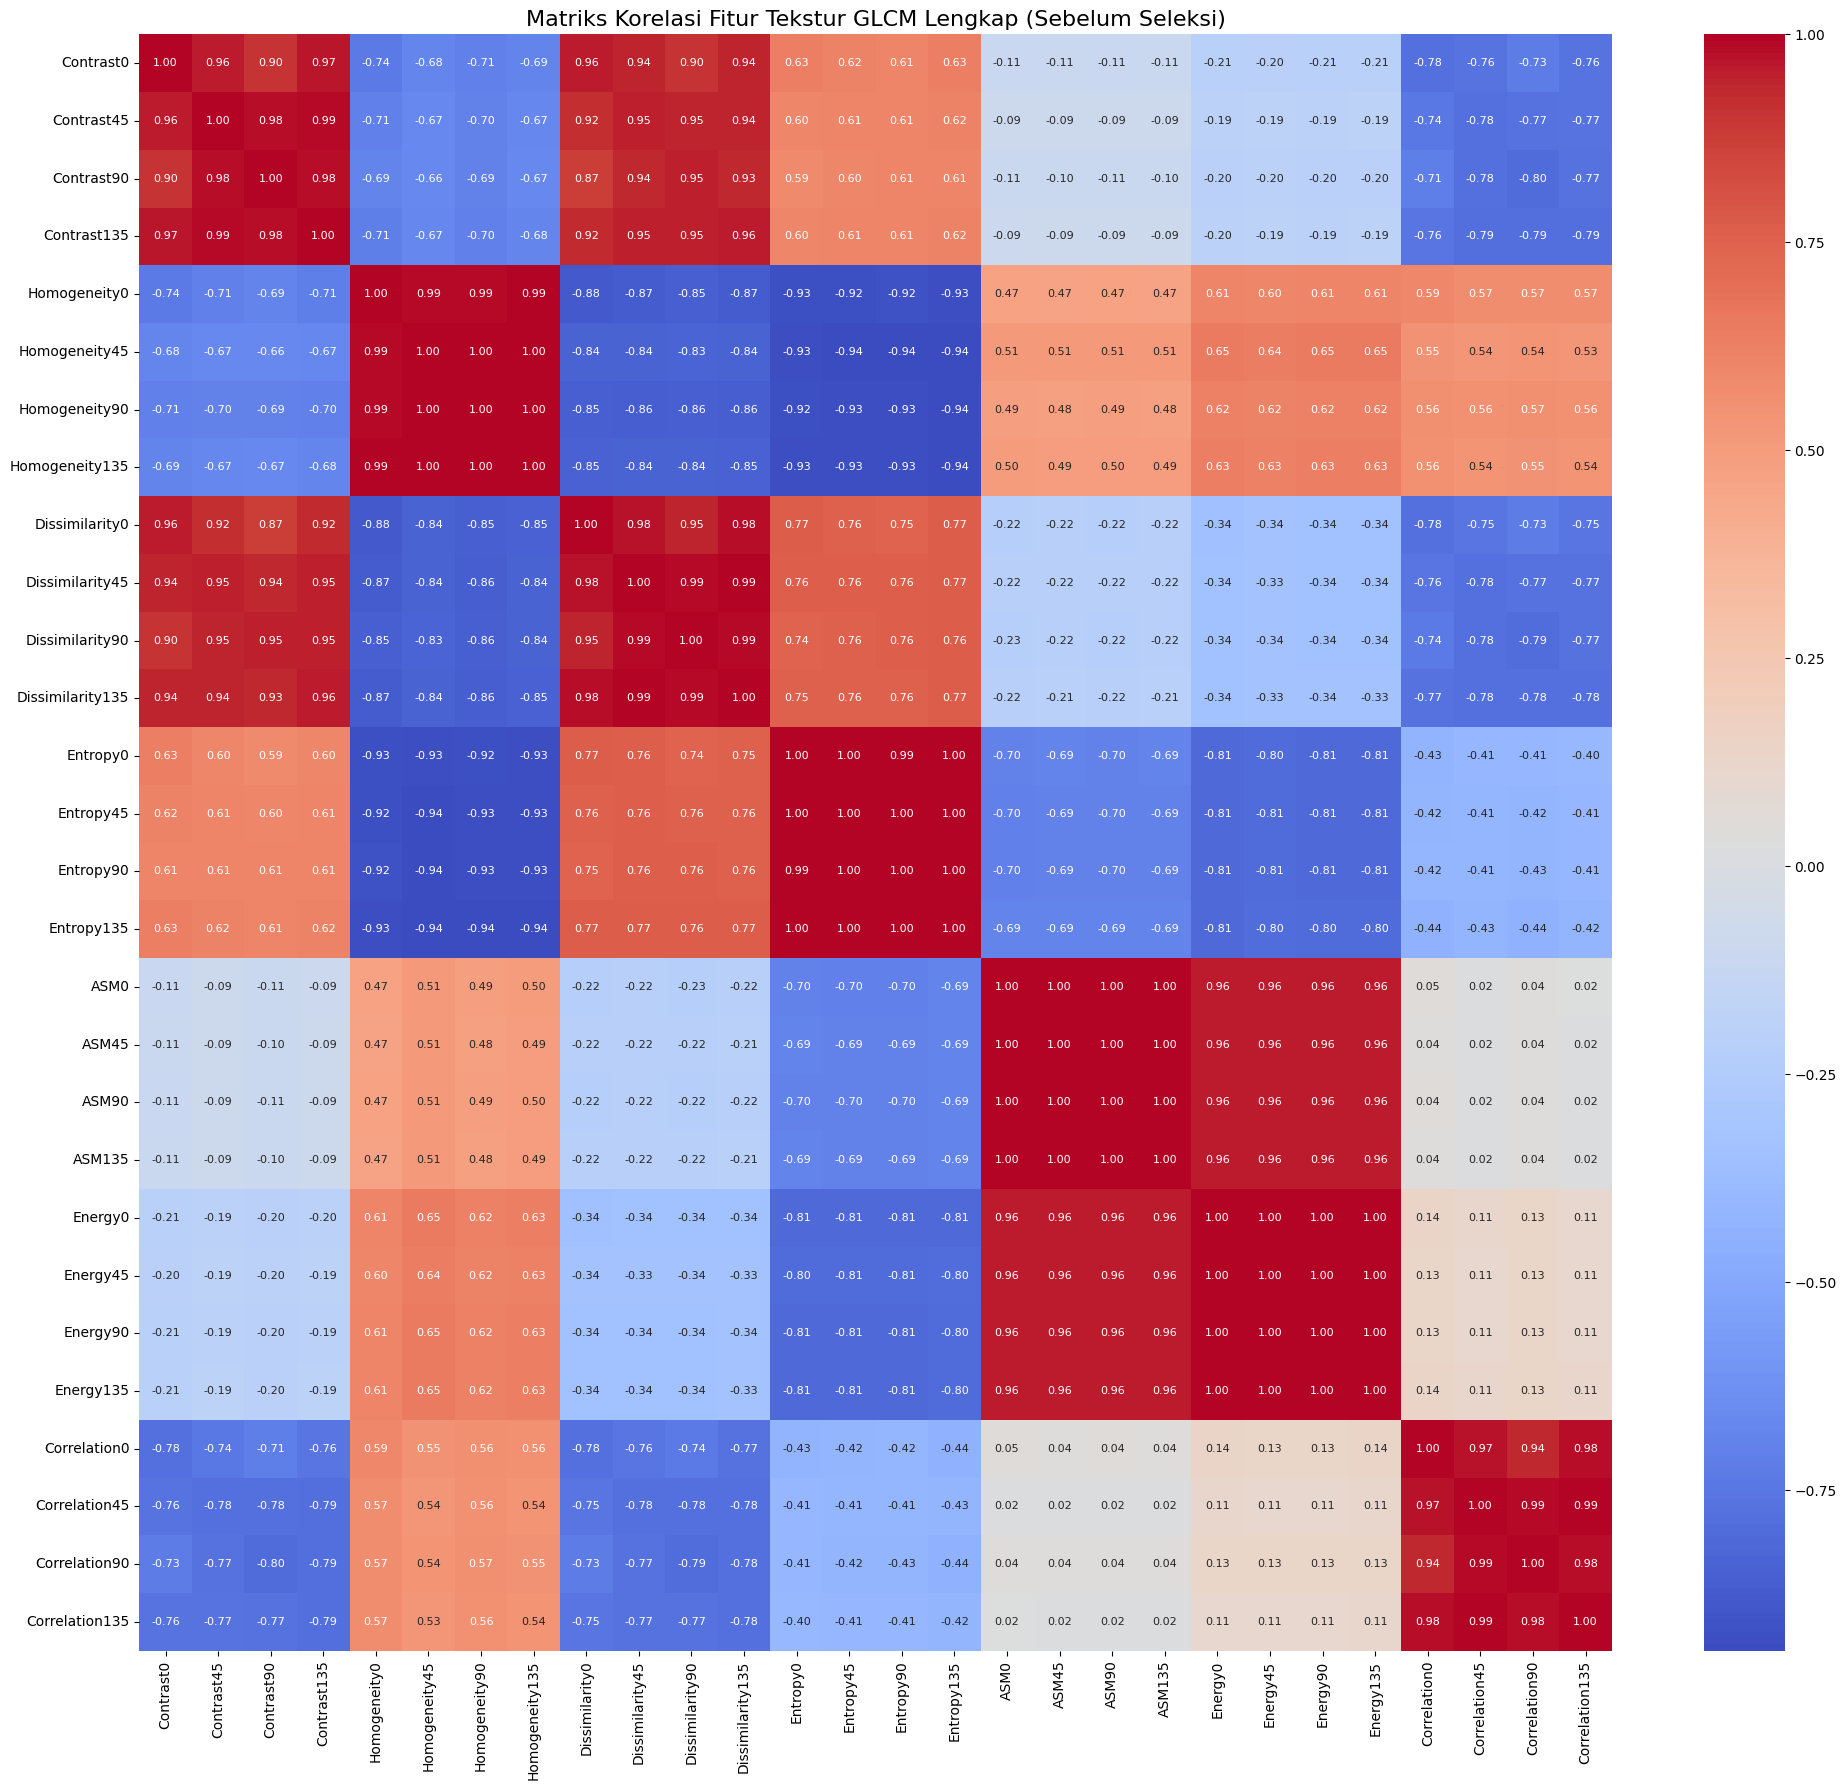

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 4 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'ASM0', 'Correlation0']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 75.00%
Akurasi SETELAH Seleksi Korelasi (4 fitur) : 67.50%


In [14]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap (Sebelum Seleksi)", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

## Spliting Data

In [15]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.5 = 50% data untuk testing (train/test 50/50)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.5, stratify=y, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(100, 4)
(100, 4)
(100,)
(100,)


## Penjelasan Kode Pembagian Data (Data Splitting)

Kode di atas digunakan untuk membagi dataset menjadi dua bagian, yaitu data untuk melatih (training) dan data untuk menguji (testing) model machine learning. Proses ini sangat penting karena memungkinkan kita mengevaluasi seberapa baik model dapat memprediksi data yang belum pernah dilihatnya sebelumnya, sehingga kita dapat mendeteksi apakah model mengalami overfitting atau tidak.

Fungsi `train_test_split()` dari sklearn menerima empat parameter utama. Parameter pertama `x_new` adalah data fitur yang sudah melewati proses seleksi korelasi sebelumnya, yang berisi hanya 4 fitur terbaik yaitu Contrast0, Homogeneity0, ASM0, dan Correlation0. Parameter kedua `y` adalah label kelas yang menunjukkan apakah setiap gambar termasuk jamur Agaricus atau Amanita. Parameter `test_size=0.2` menentukan bahwa 20 persen dari total 140 data (sekitar 28 gambar) akan digunakan sebagai data testing, sedangkan sisanya 80 persen (112 gambar) akan digunakan sebagai data training. Parameter `random_state=42` memastikan bahwa pembagian data bersifat konsisten dan dapat direproduksi, artinya setiap kali kode dijalankan hasilnya akan sama.

Hasil dari `train_test_split()` adalah empat variabel. `X_train` menyimpan fitur-fitur dari data training, `X_test` menyimpan fitur-fitur dari data testing, `y_train` menyimpan label kelas dari data training, dan `y_test` menyimpan label kelas dari data testing. Empat baris print di akhir kode menampilkan bentuk (shape) dari masing-masing variabel tersebut. Output yang diharapkan adalah X_train memiliki bentuk (112, 4) karena ada 112 sampel training dengan 4 fitur, X_test memiliki bentuk (28, 4) karena ada 28 sampel testing dengan 4 fitur, y_train memiliki bentuk (112,) karena ada 112 label untuk training, dan y_test memiliki bentuk (28,) karena ada 28 label untuk testing. Dengan cara ini, model akan dilatih menggunakan data training dan kemudian dievaluasi kinerjanya pada data testing yang sama sekali terpisah, memberikan gambaran akurat tentang kemampuan generalisasi model.

In [16]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Penjelasan Normalisasi Data (Standardization)

Kode di atas melakukan proses normalisasi data menggunakan metode standardisasi atau Z-score normalization. Normalisasi adalah langkah penting dalam persiapan data untuk machine learning karena memastikan bahwa semua fitur memiliki skala yang sama, sehingga model dapat belajar dengan lebih efektif dan tidak bias terhadap fitur yang memiliki nilai lebih besar.

Proses normalisasi bekerja dengan mengurangi setiap nilai data dengan rata-rata (mean) dari data training, kemudian membagi hasilnya dengan standar deviasi (standard deviation) dari data training. Rumus ini mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1, yang disebut sebagai distribusi normal standar. Pada kode tersebut, `X_train.mean()` menghitung nilai rata-rata dari setiap kolom fitur dalam data training, dan `X_train.std()` menghitung standar deviasi dari setiap kolom yang sama.

Penting untuk diperhatikan bahwa normalisasi menggunakan statistik (mean dan std) yang dihitung dari data training saja, bukan dari data testing. Hal ini dilakukan karena dalam praktik machine learning yang sesungguhnya, data testing dianggap sebagai data baru yang belum pernah dilihat sebelumnya, sehingga kita tidak boleh menggunakan informasi dari data testing untuk melakukan normalisasi. Dengan cara ini, proses normalisasi menjadi konsisten dan realistis. Setelah normalisasi, kedua dataset (training dan testing) akan memiliki skala yang konsisten berdasarkan karakteristik data training, sehingga model dapat melakukan prediksi dengan lebih akurat pada data testing yang belum pernah dilatih sebelumnya.

## Modeling

### Define Model

In [17]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Penjelasan Fungsi dan Definisi Model Klasifikasi

Kode di atas mendefinisikan sebuah fungsi bernama `generateClassificationReport` yang dirancang untuk mengevaluasi performa suatu model klasifikasi dengan cara yang komprehensif dan mudah dipahami. Fungsi ini menerima dua parameter, yaitu `y_true` yang berisi label kelas yang sebenarnya dari data uji, dan `y_pred` yang berisi prediksi label kelas yang dihasilkan oleh model. Ketika fungsi dipanggil, ia akan menampilkan tiga informasi penting secara berurutan. Pertama, `classification_report` menampilkan laporan detail yang mencakup metrik evaluasi seperti precision (ketepatan), recall (kelengkapan), dan F1-score untuk setiap kelas, sehingga kita dapat melihat bagaimana performa model pada masing-masing jenis jamur. Kedua, `confusion_matrix` menampilkan matriks kebingungan yang menunjukkan berapa banyak sampel yang diklasifikasikan dengan benar dan berapa banyak yang salah, dalam bentuk tabel yang mudah dipahami. Ketiga, `accuracy_score` menampilkan akurasi keseluruhan model, yaitu persentase prediksi yang benar dari total semua prediksi.

Setelah mendefinisikan fungsi evaluasi, kode kemudian membuat tiga model klasifikasi yang berbeda untuk digunakan dalam tahap pelatihan dan pengujian. Model pertama adalah `RandomForestClassifier` dengan parameter `n_estimators=5` yang berarti model akan menggunakan 5 pohon keputusan (decision trees) yang bekerja secara paralel dan independen, kemudian hasil prediksi dari semua pohon akan digabungkan untuk menghasilkan prediksi final yang lebih akurat dan stabil. Model kedua adalah `SVC` (Support Vector Classifier) dengan kernel `rbf` (Radial Basis Function), yang merupakan algoritma klasifikasi yang mencari hyperplane optimal untuk memisahkan kedua kelas jamur dengan margin yang sebesar mungkin, dan kernel `rbf` memungkinkan model untuk menangani pola nonlinier yang kompleks. Model ketiga adalah `KNeighborsClassifier` dengan parameter `n_neighbors=5`, yang berarti model akan mengklasifikasikan sampel baru berdasarkan 5 tetangga terdekat dalam ruang fitur, mengambil kelas yang paling sering muncul di antara 5 tetangga tersebut. Semua tiga model menggunakan `random_state=42` untuk memastikan hasil yang konsisten dan dapat direproduksi saat kode dijalankan kembali, sehingga memudahkan perbandingan performa antar model.

### Train Random Forest Classifier

## Penjelasan Pelatihan dan Evaluasi Model Random Forest

Kode di bawah digunakan untuk melatih model Random Forest dan kemudian mengevaluasi kinerjanya menggunakan dua dataset terpisah yaitu data pelatihan dan data pengujian. Proses dimulai dengan memanggil fungsi `fit()` pada objek model `rf` (Random Forest) sambil memberikan dua parameter: `X_train` yang berisi fitur-fitur terpilih dari data pelatihan (Contrast0, Homogeneity0, ASM0, dan Correlation0), dan `y_train` yang berisi label kelas yang sesuai (Agaricus atau Amanita). Fungsi `fit()` ini melatih model dengan menggunakan data pelatihan sehingga model dapat belajar pola dan karakteristik yang membedakan kedua jenis jamur.

Setelah model selesai dilatih, kode kemudian melakukan evaluasi pada data pelatihan untuk melihat seberapa baik model dapat mengingat data yang telah dilihatnya. Baris pertama mencetak judul "Training Set" untuk memisahkan hasil evaluasi, kemudian fungsi `predict()` dipanggil dengan parameter `X_train` untuk membuat prediksi pada data pelatihan, hasilnya disimpan dalam variabel `y_pred`. Selanjutnya fungsi `generateClassificationReport()` dipanggil dengan membandingkan `y_train` (label sebenarnya) dengan `y_pred` (prediksi model) untuk menampilkan laporan klasifikasi lengkap yang mencakup precision, recall, F1-score, matriks kebingungan, dan akurasi keseluruhan pada data pelatihan.

Tahap terakhir adalah evaluasi pada data pengujian yang mewakili data baru yang belum pernah dilihat model sebelumnya, sehingga hasil ini memberikan gambaran yang lebih akurat tentang kemampuan model dalam dunia nyata. Kode mencetak judul "Testing Set" dan kemudian memanggil `predict()` dengan parameter `X_test` untuk membuat prediksi pada data pengujian, hasilnya juga disimpan dalam `y_pred`. Fungsi `generateClassificationReport()` dipanggil lagi dengan membandingkan `y_test` (label sebenarnya dari data pengujian) dengan prediksi model untuk menampilkan metrik evaluasi lengkap. Dengan membandingkan hasil akurasi antara data pelatihan dan data pengujian, kita dapat mendeteksi apakah model mengalami overfitting (akurasi pelatihan jauh lebih tinggi dari pengujian) atau underfitting (kedua akurasi rendah), sehingga membantu menentukan apakah model siap digunakan atau perlu penyesuaian lebih lanjut.

In [18]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Agaricus       1.00      1.00      1.00        50
     Amanita       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[50  0]
 [ 0 50]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

    Agaricus       0.59      0.74      0.65        50
     Amanita       0.65      0.48      0.55        50

    accuracy                           0.61       100
   macro avg       0.62      0.61      0.60       100
weighted avg       0.62      0.61      0.60       100

[[37 13]
 [26 24]]
Accuracy: 0.61


### Train SVM Classifier

## Penjelasan Pelatihan dan Evaluasi Model SVM

Kode di bawah digunakan untuk melatih model Support Vector Machine (SVM) dan kemudian mengevaluasi kinerjanya menggunakan dua dataset terpisah yaitu data pelatihan dan data pengujian. Proses dimulai dengan memanggil fungsi `fit()` pada objek model `svm` sambil memberikan dua parameter: `X_train` yang berisi empat fitur terpilih dari data pelatihan (Contrast0, Homogeneity0, ASM0, dan Correlation0), dan `y_train` yang berisi label kelas yang sesuai (Agaricus atau Amanita). Fungsi `fit()` ini melatih model SVM dengan mencari hyperplane optimal yang dapat memisahkan kedua kelas jamur dengan margin maksimal dalam ruang fitur berdimensi empat.

Setelah model SVM selesai dilatih, kode kemudian melakukan evaluasi pada data pelatihan untuk melihat seberapa baik model dapat mengingat data yang telah dilihatnya selama proses pembelajaran. Baris pertama mencetak judul "Training Set" dengan karakter baru di awal (`\n`) untuk memisahkan hasil evaluasi dengan output sebelumnya, kemudian fungsi `predict()` dipanggil dengan parameter `X_train` untuk membuat prediksi pada data pelatihan, hasilnya disimpan dalam variabel `y_pred`. Selanjutnya fungsi `generateClassificationReport()` dipanggil dengan membandingkan `y_train` (label sebenarnya) dengan `y_pred` (prediksi model) untuk menampilkan laporan klasifikasi lengkap yang mencakup precision, recall, F1-score, matriks kebingungan, dan akurasi keseluruhan pada data pelatihan.

Tahap terakhir adalah evaluasi pada data pengujian yang mewakili data baru yang belum pernah dilihat model SVM sebelumnya, sehingga hasil ini memberikan gambaran yang lebih akurat tentang kemampuan model dalam melakukan prediksi pada kasus nyata di lapangan. Kode mencetak judul "Testing Set" dan kemudian memanggil `predict()` dengan parameter `X_test` untuk membuat prediksi pada data pengujian, hasilnya juga disimpan dalam variabel `y_pred`. Fungsi `generateClassificationReport()` dipanggil kembali dengan membandingkan `y_test` (label sebenarnya dari data pengujian) dengan prediksi model untuk menampilkan metrik evaluasi lengkap. Dengan membandingkan hasil akurasi antara data pelatihan dan data pengujian pada model SVM, kita dapat mendeteksi apakah model mengalami overfitting atau underfitting, sehingga membantu menentukan apakah algoritma SVM cocok untuk klasifikasi jamur ini atau perlu penyesuaian parameter kernel dan hyperparameter lainnya.

In [19]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Agaricus       0.69      0.90      0.78        50
     Amanita       0.86      0.60      0.71        50

    accuracy                           0.75       100
   macro avg       0.77      0.75      0.74       100
weighted avg       0.77      0.75      0.74       100

[[45  5]
 [20 30]]
Accuracy: 0.75

------Testing Set------
              precision    recall  f1-score   support

    Agaricus       0.57      0.92      0.70        50
     Amanita       0.79      0.30      0.43        50

    accuracy                           0.61       100
   macro avg       0.68      0.61      0.57       100
weighted avg       0.68      0.61      0.57       100

[[46  4]
 [35 15]]
Accuracy: 0.61


### Train KNN Classifier

## Penjelasan Pelatihan dan Evaluasi Model KNN

Kode di bawah digunakan untuk melatih model K-Nearest Neighbors (KNN) dan kemudian mengevaluasi kinerjanya menggunakan dua dataset terpisah yaitu data pelatihan dan data pengujian. Proses dimulai dengan memanggil fungsi `fit()` pada objek model `knn` sambil memberikan dua parameter: `X_train` yang berisi empat fitur terpilih dari data pelatihan (Contrast0, Homogeneity0, ASM0, dan Correlation0), dan `y_train` yang berisi label kelas yang sesuai (Agaricus atau Amanita). Fungsi `fit()` ini melatih model KNN dengan menyimpan semua data pelatihan dalam memori, sehingga nantinya model dapat membandingkan sampel baru dengan data-data pelatihan yang sudah disimpan tersebut.

Setelah model KNN selesai dilatih, kode kemudian melakukan evaluasi pada data pelatihan untuk melihat seberapa baik model dapat mengingat data yang telah dilihatnya selama proses pembelajaran. Baris pertama mencetak judul "Training Set" dengan karakter baris baru di awal (`\n`) untuk memisahkan hasil evaluasi dengan output sebelumnya, kemudian fungsi `predict()` dipanggil dengan parameter `X_train` untuk membuat prediksi pada data pelatihan, hasilnya disimpan dalam variabel `y_pred`. Selanjutnya fungsi `generateClassificationReport()` dipanggil dengan membandingkan `y_train` (label sebenarnya) dengan `y_pred` (prediksi model) untuk menampilkan laporan klasifikasi lengkap yang mencakup precision, recall, F1-score, matriks kebingungan, dan akurasi keseluruhan pada data pelatihan.

Tahap terakhir adalah evaluasi pada data pengujian yang mewakili data baru yang belum pernah dilihat model KNN sebelumnya, sehingga hasil ini memberikan gambaran yang lebih realistis tentang kemampuan model dalam melakukan prediksi pada kasus nyata. Kode mencetak judul "Testing Set" dan kemudian memanggil `predict()` dengan parameter `X_test` untuk membuat prediksi pada data pengujian, hasilnya juga disimpan dalam variabel `y_pred`. Fungsi `generateClassificationReport()` dipanggil kembali dengan membandingkan `y_test` (label sebenarnya dari data pengujian) dengan prediksi model untuk menampilkan metrik evaluasi lengkap. Dengan membandingkan hasil akurasi antara data pelatihan dan data pengujian pada model KNN, kita dapat mengevaluasi apakah algoritma KNN dengan parameter `n_neighbors=5` cocok untuk klasifikasi jamur ini atau perlu penyesuaian jumlah tetangga terdekat yang digunakan.

In [20]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Agaricus       0.72      0.84      0.78        50
     Amanita       0.81      0.68      0.74        50

    accuracy                           0.76       100
   macro avg       0.77      0.76      0.76       100
weighted avg       0.77      0.76      0.76       100

[[42  8]
 [16 34]]
Accuracy: 0.76

------Testing Set------
              precision    recall  f1-score   support

    Agaricus       0.61      0.84      0.71        50
     Amanita       0.74      0.46      0.57        50

    accuracy                           0.65       100
   macro avg       0.68      0.65      0.64       100
weighted avg       0.68      0.65      0.64       100

[[42  8]
 [27 23]]
Accuracy: 0.65


### Evaluasi Dengan Confussion Matrix

## Penjelasan Visualisasi Matriks Kebingungan (Confusion Matrix)

Kode di bawah digunakan untuk membuat visualisasi matriks kebingungan (confusion matrix) dari ketiga model klasifikasi yang telah dilatih sebelumnya, yaitu Random Forest, SVM, dan KNN. Matriks kebingungan adalah alat yang sangat berguna untuk memahami performa model secara detail, karena menunjukkan berapa banyak sampel yang diklasifikasikan dengan benar dan berapa banyak yang salah untuk setiap kelas.

Fungsi `plot_confusion_matrix` menerima tiga parameter: `y_true` yang berisi label kelas sebenarnya dari data pengujian, `y_pred` yang berisi prediksi label kelas dari model, dan `title` yang merupakan judul untuk grafik. Proses dimulai dengan menghitung matriks kebingungan menggunakan fungsi `confusion_matrix()` yang membandingkan label sebenarnya dengan prediksi model. Hasilnya adalah sebuah matriks 2x2 (untuk klasifikasi biner antara Agaricus dan Amanita) yang menunjukkan empat nilai: true negatives (sampel Agaricus yang diprediksi benar sebagai Agaricus), false positives (sampel Agaricus yang salah diprediksi sebagai Amanita), false negatives (sampel Amanita yang salah diprediksi sebagai Agaricus), dan true positives (sampel Amanita yang diprediksi benar sebagai Amanita).

Setelah matriks kebingungan dihitung, kode menggunakan `ConfusionMatrixDisplay` untuk membuat visualisasi yang mudah dipahami. Fungsi `disp.plot()` menampilkan matriks dalam bentuk heatmap dengan warna biru, di mana warna yang lebih gelap menunjukkan nilai yang lebih tinggi, sehingga memudahkan identifikasi visual performa model. Judul grafik ditambahkan menggunakan `plt.title()` dengan parameter yang diberikan, dan akhirnya grafik ditampilkan dengan `plt.show()`.

Bagian terakhir dari kode memanggil fungsi `plot_confusion_matrix()` tiga kali, masing-masing untuk ketiga model. Untuk setiap model, data pengujian `X_test` diprediksi menggunakan model tersebut (`.predict(X_test)`), kemudian hasilnya dibandingkan dengan label sebenarnya `y_test` untuk menghasilkan visualisasi matriks kebingungan yang spesifik untuk setiap model. Dengan cara ini, Anda dapat secara visual membandingkan performa ketiga model dan melihat mana yang paling akurat dalam mengklasifikasikan kedua jenis jamur.

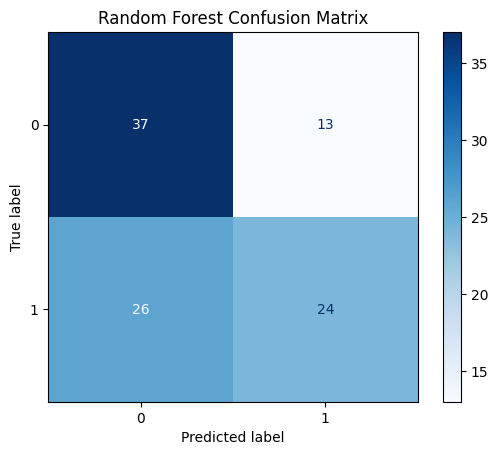

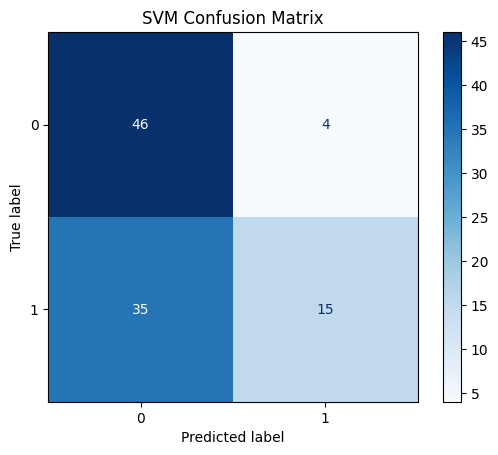

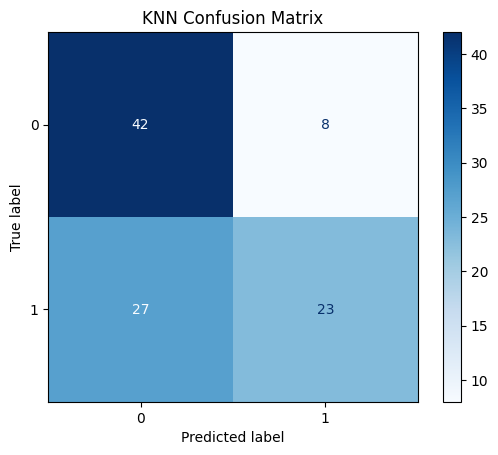

In [21]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

# Tabel Perbandingan Akurasi Training dan Testing Antar Percobaan
## Percobaan 2

| Algoritma     | Training P2 | Testing P2 |
| ------------- | ----------- | ---------- |
| Random Forest | 100.00%     | 61.00%     |
| SVM           | 75.00%      | 61.00%     |
| KNN           | 76.00%      | 65.00%     |
